# Stage 2: Finding the Geothermal Resource

This notebook works out **where the heat is**, **how much power we can safely count on**, and **where to drill** to supply a district that needs heating. Geothermal energy comes from pumping hot water up from deep rock through a pair of wells called a **doublet** (one well brings hot water up, the other sends the cooled water back down). Because we can never be certain how much a well will deliver, we report power as a range of probabilities rather than a single number, then map the resource across the whole area and recommend a new well that sits close to the people who need the heat.

Why it matters for the challenge: Challenge 1 (60% of the score) is about proving a viable, low-risk resource and a credible drilling plan. This notebook produces exactly that evidence plus the two headline figures used in the report and deck.

**How to run:** Run the cells top to bottom (Kernel → Restart & Run All). The first code cell imports the project's `geothermal` package and creates an output folder for figures; everything after it is self-contained and prints results and saves the two figures into `outputs/figures/phase2/`.

In [1]:
from __future__ import annotations

import matplotlib

matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np

from geothermal import config
from geothermal.resource import (
    locate_demand_center,
    recommend_new_well,
    resource_grid,
    well_power_percentiles,
)

FIG_DIR = config.OUTPUTS_DIR / "figures" / "phase2"
FIG_DIR.mkdir(parents=True, exist_ok=True)

## Section 1: How much power can each well deliver?

Each existing well's potential is summarized with three numbers: **P90** (a cautious estimate we'd beat 90% of the time), **P50** (the middle, most-likely case), and **P10** (an optimistic upside). These come from the model calibrated against ThermoGIS, the public Dutch geothermal database. Look for which wells have a positive P50 — those are the ones actually worth developing — and note how wide the P90-to-P10 gap is, which shows how risky relying on a single well would be.

In [2]:
print("=" * 78)
print("SECTION 1 — PER-WELL DOUBLET POWER (P90 / P50 / P10), calibrated to ThermoGIS")
print("=" * 78)
pct = well_power_percentiles()
print(pct.round(2).to_string())
print("\nViable wells (P50 > 0): BLT-01 and JUT-01 only — EVD/PKP are too tight.")
print(
    f"Single-well risk is large: BLT-01 spans P90={pct.loc['BLT-01', 'P90']:.1f} → "
    f"P50={pct.loc['BLT-01', 'P50']:.1f} → P10={pct.loc['BLT-01', 'P10']:.1f} MW."
)

SECTION 1 — PER-WELL DOUBLET POWER (P90 / P50 / P10), calibrated to ThermoGIS
         P90   P50    P10  thermogis_P50
BLT-01  0.72  5.13  23.21            5.1
EVD-01  0.00  0.00   0.00            0.0
JUT-01  1.05  2.30   4.98            2.3
PKP-01  0.00  0.00   0.00            0.0

Viable wells (P50 > 0): BLT-01 and JUT-01 only — EVD/PKP are too tight.
Single-well risk is large: BLT-01 spans P90=0.7 → P50=5.1 → P10=23.2 MW.


## Section 2: Where is the demand, and where should the new well go?

The district that needs heating is centered on a demand point we call the **USP**. We pin down its location by **trilateration** — the same distance-from-known-points trick GPS uses. We then ask the model to recommend the best spot for a brand-new doublet. Look for the demand centre coordinates and the recommended well's location and its P50 power.

In [3]:
print("\n" + "=" * 78)
print("SECTION 2 — DEMAND CENTRE & NEW-WELL SITING")
print("=" * 78)
usp_x, usp_y = locate_demand_center()
print(f"Demand centre (USP) trilaterated to x={usp_x:.0f}, y={usp_y:.0f} (RD New).")
rec = recommend_new_well()
print("Recommended new doublet:")
for k, v in rec.items():
    print(f"  {k}: {v:.2f}")


SECTION 2 — DEMAND CENTRE & NEW-WELL SITING
Demand centre (USP) trilaterated to x=141171, y=454890 (RD New).


Recommended new doublet:
  x: 141302.39
  y: 455406.57
  transmissivity_dm: 8.66
  temperature_c: 76.83
  power_mw_p50: 4.76
  distance_to_usp_km: 0.53
  distance_to_blt_km: 1.50


## Section 3: A drilling programme that meets the 10 MWth target

The district needs about **10 MWth** of heating capacity (MWth = megawatts of thermal, i.e. heat, power). Here we add up the most-likely (P50) output of the proven well plus the recommended new well to show that two doublets near the demand already clear the target, with a third optional well for resilience and upside. The final well count is settled later in Phase 4, where cost is weighed against capacity.

In [4]:
print("\n" + "=" * 78)
print("SECTION 3 — RECOMMENDED WELL PROGRAMME")
print("=" * 78)
blt_p50 = float(pct.loc["BLT-01", "P50"])
jut_p50 = float(pct.loc["JUT-01", "P50"])
new_p50 = rec["power_mw_p50"]
print(f"  Doublet A — BLT-01 area      : {blt_p50:4.1f} MWth (P50, proven)")
print(f"  Doublet B — new step-out     : {new_p50:4.1f} MWth (P50, 1.5 km SW of BLT, 0.5 km from USP)")
print(f"  → two doublets near demand   : {blt_p50 + new_p50:4.1f} MWth (P50)  ✓ meets 10 MWth target")
print(f"  Doublet C — JUT-01 (optional): {jut_p50:4.1f} MWth — resilience / upside (7.7 km from USP)")
print(f"  Full three-doublet programme : {blt_p50 + new_p50 + jut_p50:4.1f} MWth (P50)")
print("\n  Final well count is set in Phase 4 by the LCoE optimisation (cost vs capacity).")


SECTION 3 — RECOMMENDED WELL PROGRAMME
  Doublet A — BLT-01 area      :  5.1 MWth (P50, proven)
  Doublet B — new step-out     :  4.8 MWth (P50, 1.5 km SW of BLT, 0.5 km from USP)
  → two doublets near demand   :  9.9 MWth (P50)  ✓ meets 10 MWth target
  Doublet C — JUT-01 (optional):  2.3 MWth — resilience / upside (7.7 km from USP)
  Full three-doublet programme : 12.2 MWth (P50)

  Final well count is set in Phase 4 by the LCoE optimisation (cost vs capacity).


## Figure 1 - The resource power map

This map fills in the gaps between our four wells using **IDW** (inverse-distance weighting — nearby wells count more than far ones) to estimate doublet power everywhere across the area. Brighter colours mean more power. Circles are viable wells, X marks are too-tight ones, the red star is the demand centre, and the cyan marker is the recommended new well. Look for the recommended well sitting in a bright zone close to the demand star.

/tmp/claude-501/ipykernel_9940/2944499488.py:8: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(w.x, w.y, c="white", edgecolors="k", s=80, marker="o" if viable else "x")


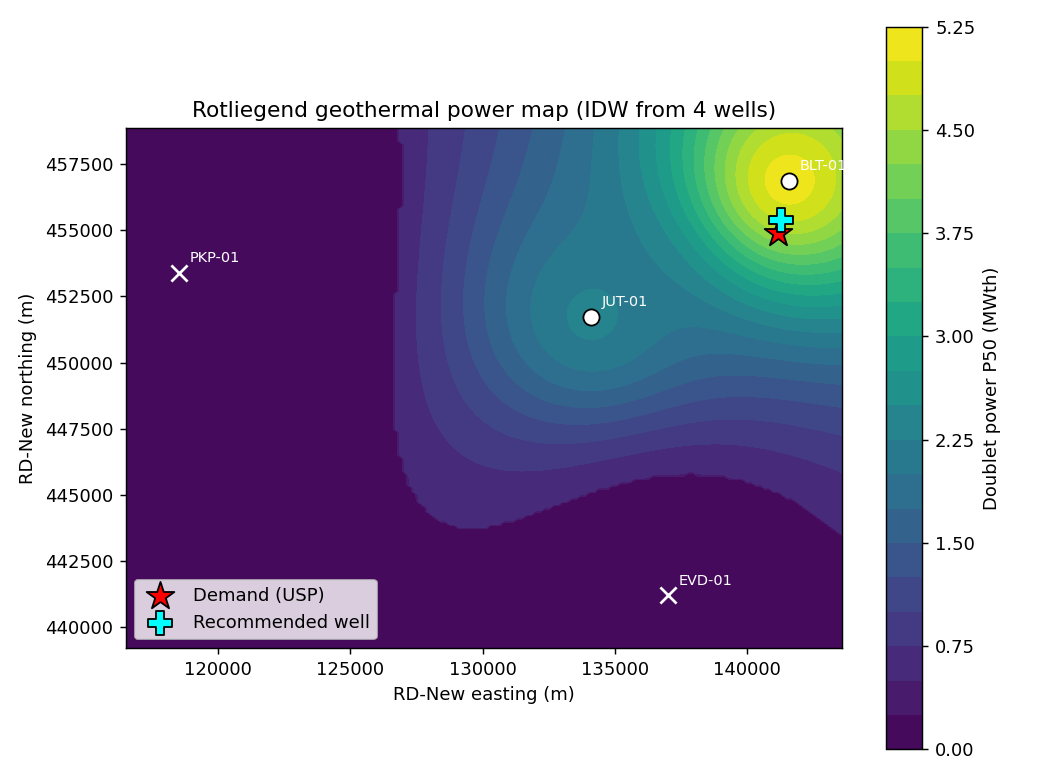

In [5]:
grid = resource_grid(160)
fig, ax = plt.subplots(figsize=(8, 6))
cf = ax.contourf(grid.x, grid.y, grid.power_mw, levels=20, cmap="viridis")
fig.colorbar(cf, ax=ax, label="Doublet power P50 (MWth)")
for wid in config.WELL_IDS:
    w = config.WELLS[wid]
    viable = float(pct.loc[wid, "P50"]) > 0
    ax.scatter(w.x, w.y, c="white", edgecolors="k", s=80, marker="o" if viable else "x")
    ax.annotate(wid, (w.x, w.y), textcoords="offset points", xytext=(6, 6), color="white", fontsize=8)
ax.scatter(usp_x, usp_y, c="red", marker="*", s=260, edgecolors="k", label="Demand (USP)")
ax.scatter(rec["x"], rec["y"], c="cyan", marker="P", s=180, edgecolors="k", label="Recommended well")
ax.set_xlabel("RD-New easting (m)")
ax.set_ylabel("RD-New northing (m)")
ax.set_title("Rotliegend geothermal power map (IDW from 4 wells)")
ax.legend(loc="lower left")
ax.set_aspect("equal")
fig.tight_layout()
fig.savefig(FIG_DIR / "resource_power_map.png", dpi=130)

from IPython.display import Image as _Image

_Image(str(FIG_DIR / "resource_power_map.png"))

## Figure 2 - Per-well power with its uncertainty range

This bar chart shows each well's P50 power with error bars spanning the cautious P90 to the optimistic P10, so the uncertainty is visible at a glance. The dashed red line marks the 10 MWth heating target. Look for which bars clear or approach the line and how tall the error bars are — a tall bar means more uncertainty about that well.


Figures written to /Users/vadmin/Documents/Lab/Projects/DSEATS/June26GeoDatathon/outputs/figures/phase2


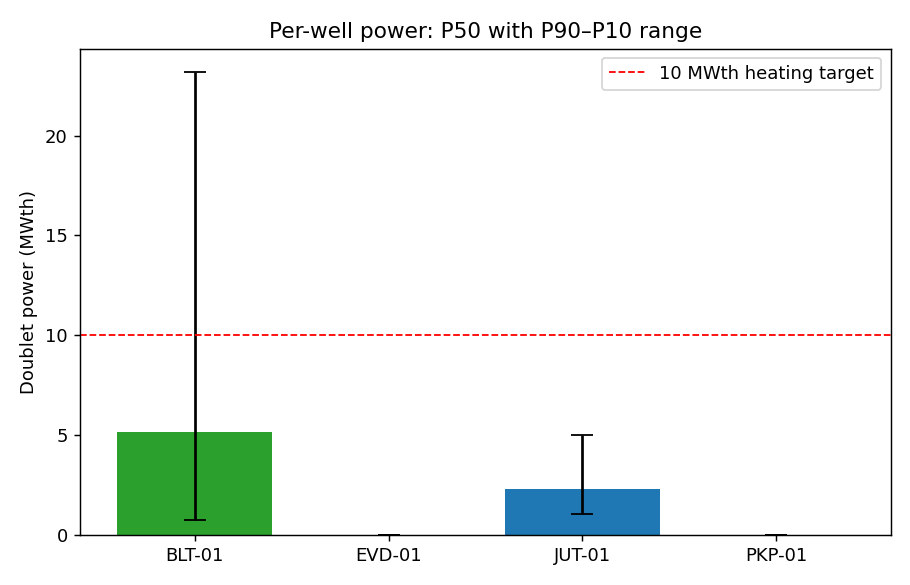

In [6]:
fig, ax = plt.subplots(figsize=(7, 4.5))
wells = config.WELL_IDS
p50 = [float(pct.loc[w, "P50"]) for w in wells]
lo = [float(pct.loc[w, "P50"]) - float(pct.loc[w, "P90"]) for w in wells]
hi = [float(pct.loc[w, "P10"]) - float(pct.loc[w, "P50"]) for w in wells]
ax.bar(wells, p50, yerr=[lo, hi], capsize=6, color=["tab:green", "tab:gray", "tab:blue", "tab:gray"])
ax.axhline(10, color="red", ls="--", lw=1, label="10 MWth heating target")
ax.set_ylabel("Doublet power (MWth)")
ax.set_title("Per-well power: P50 with P90–P10 range")
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "well_power_percentiles.png", dpi=130)

print(f"\nFigures written to {FIG_DIR}")

from IPython.display import Image as _Image

_Image(str(FIG_DIR / "well_power_percentiles.png"))